In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_file_path = "superconductivty+data/train.csv"
labels_path = "superconductivty+data/unique_m.csv"

df = pd.read_csv(train_file_path)
df_labels = pd.read_csv(labels_path)

X = df.drop(columns=["critical_temp"])
Y = df_labels["critical_temp"]

In [4]:
print("=== BASIC INFO ===")
print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nTarget range: {Y.min():.2f} to {Y.max():.2f}")
print(f"Target mean: {Y.mean():.2f}, std: {Y.std():.2f}")

print("\n=== MISSING VALUES ===")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in Y: {Y.isnull().sum()}")

print("\n=== DATA TYPES ===")
print(X.dtypes.value_counts())

print("\n=== FIRST FEW ROWS ===")
display(X.head())

=== BASIC INFO ===
Dataset shape: (21263, 81)
Number of features: 81
Number of samples: 21263

Target range: 0.00 to 185.00
Target mean: 34.42, std: 34.25

=== MISSING VALUES ===
Missing values in X: 0
Missing values in Y: 0

=== DATA TYPES ===
float64    78
int64       3
Name: count, dtype: int64

=== FIRST FEW ROWS ===


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.25,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.00,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.25,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.25,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.25,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809


In [5]:
print("\n=== FEATURE STATISTICS ===")
stats = pd.DataFrame({
    'mean': X.mean(),
    'std': X.std(),
    'min': X.min(),
    'max': X.max(),
})
display(stats.head(20))

# Identify near-constant features
constant_threshold = 0.95
constant_features = []
for col in X.columns:
    if X[col].value_counts(normalize=True).iloc[0] > constant_threshold:
        constant_features.append(col)
print(f"\nNear-constant features (>95% same value): {len(constant_features)}")
print(constant_features[:10])


=== FEATURE STATISTICS ===


,mean,std,min,max
number_of_elements,4.115224,1.439295,1.000000,9.000000
mean_atomic_mass,87.557631,29.676497,6.941000,208.980400
wtd_mean_atomic_mass,72.988310,33.490406,6.423452,208.980400
gmean_atomic_mass,71.290627,31.030272,5.320573,208.980400
wtd_gmean_atomic_mass,58.539916,36.651067,1.960849,208.980400
entropy_atomic_mass,1.165608,0.364930,0.000000,1.983797
wtd_entropy_atomic_mass,1.063884,0.401423,0.000000,1.958203
range_atomic_mass,115.601251,54.626887,0.000000,207.972460
wtd_range_atomic_mass,33.225218,26.967752,0.000000,205.589910
std_atomic_mass,44.391893,20.035430,0.000000,101.019700



Near-constant features (>95% same value): 0
[]



=== TOP 10 FEATURES CORRELATED WITH CRITICAL TEMP ===
wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_mean_Valence               0.632401
wtd_entropy_atomic_mass        0.626930
wtd_gmean_Valence              0.615653
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
dtype: float64

=== BOTTOM 10 FEATURES CORRELATED WITH CRITICAL TEMP ===
range_FusionHeat                   0.140714
wtd_entropy_ThermalConductivity    0.116728
std_Density                        0.115243
mean_atomic_mass                   0.113523
wtd_mean_ElectronAffinity          0.111516
wtd_gmean_ElectronAffinity         0.107359
mean_atomic_radius                 0.105273
mean_fie                           0.102268
entropy_ThermalConductivity        0.085862
gmean_fie                          0.025103
dtype: float64

Highly correlate

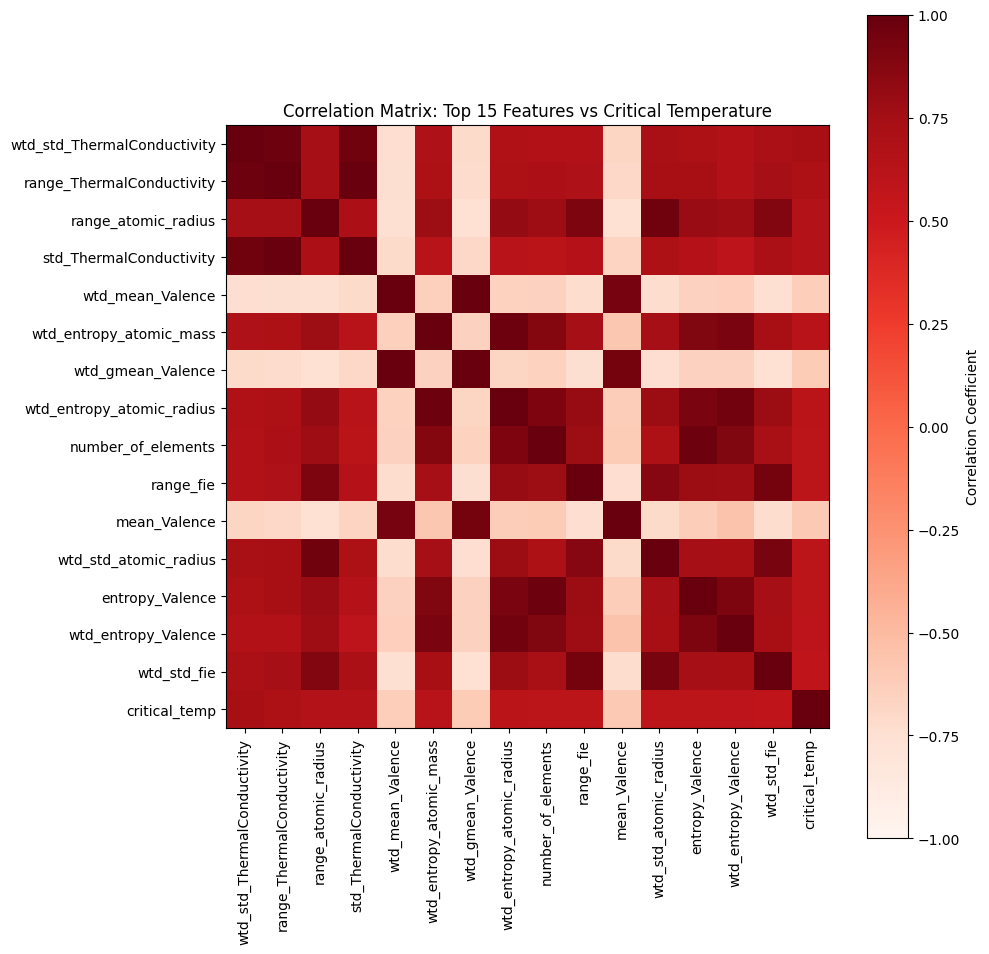

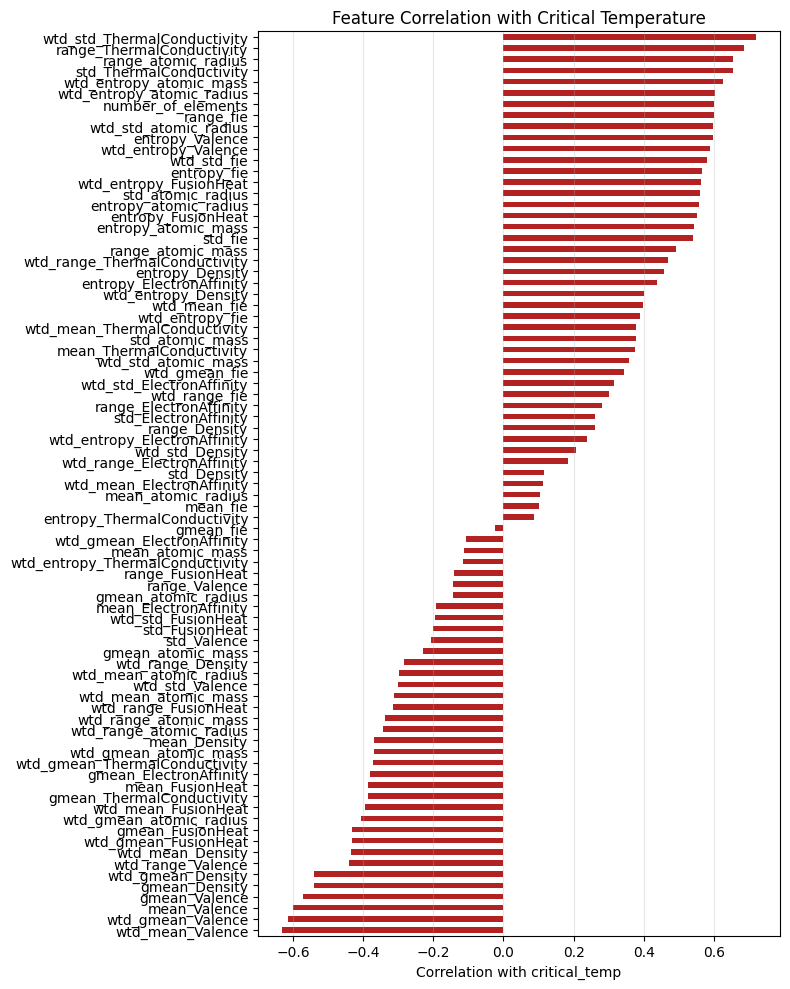

In [18]:
# Correlation with target
correlations = X.corrwith(Y).abs().sort_values(ascending=False)
print("\n=== TOP 10 FEATURES CORRELATED WITH CRITICAL TEMP ===")
print(correlations.head(10))

print("\n=== BOTTOM 10 FEATURES CORRELATED WITH CRITICAL TEMP ===")
print(correlations.tail(10))

# Feature-feature correlation matrix (for multicollinearity)
corr_matrix = X.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, upper_tri[col].idxmax(), upper_tri[col].max()) 
                   for col in upper_tri.columns if upper_tri[col].max() > 0.95]
print(f"\nHighly correlated feature pairs (>0.95): {len(high_corr_pairs)}")

# 1. Find the top 15 features most correlated with the target (Y)
correlations_with_target = X.corrwith(Y).abs().sort_values(ascending=False)
top_15_features = correlations_with_target.head(15).index

# 2. Create a subset DataFrame with these features AND the target variable
df_subset = X[top_15_features].copy()
df_subset['critical_temp'] = Y

# 3. Calculate the correlation matrix
corr_matrix = df_subset.corr()

# 4. Plot using matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(corr_matrix, cmap='Reds', vmin=-1, vmax=1)
fig.colorbar(cax, label='Correlation Coefficient')

# Add the tick labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

plt.title('Correlation Matrix: Top 15 Features vs Critical Temperature')
plt.tight_layout()
plt.show()

corr_target = X.corrwith(Y).sort_values()

plt.figure(figsize=(8,10))

corr_target.plot(
    kind='barh',
    color='firebrick'
)

plt.xlabel("Correlation with critical_temp")
plt.title("Feature Correlation with Critical Temperature")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


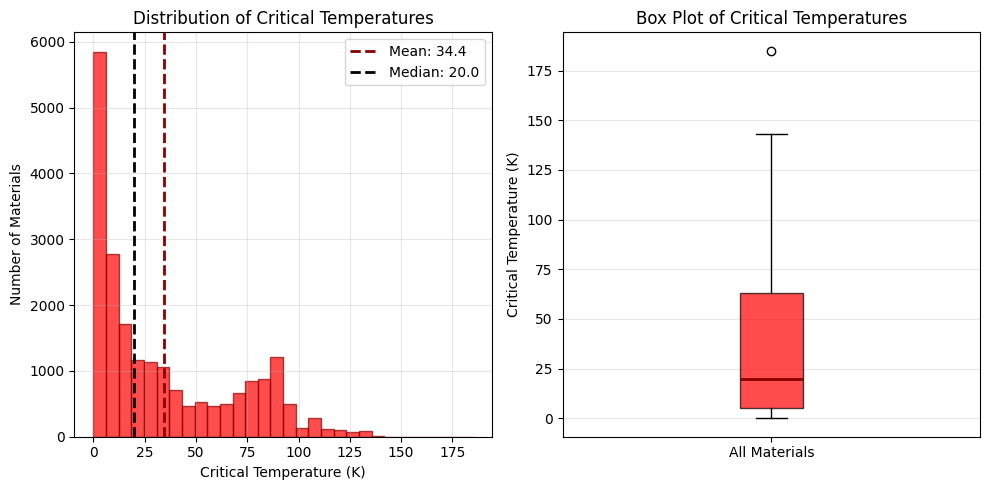


Interpretation: Most materials have critical temperatures below 20.0K
The highest temperature superconductors reach 185.0K


In [17]:
# Plot 1: Distribution of critical temperatures
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(Y, bins=30, color='red', alpha=0.7, edgecolor='darkred')
plt.xlabel('Critical Temperature (K)')
plt.ylabel('Number of Materials')
plt.title('Distribution of Critical Temperatures')
plt.grid(True, alpha=0.3)

# Add statistics lines
plt.axvline(Y.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {Y.mean():.1f}')
plt.axvline(Y.median(), color='black', linestyle='--', linewidth=2, label=f'Median: {Y.median():.1f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(Y, patch_artist=True, 
            boxprops=dict(facecolor='red', alpha=0.7),
            medianprops=dict(color='darkred', linewidth=2))
plt.ylabel('Critical Temperature (K)')
plt.title('Box Plot of Critical Temperatures')
plt.xticks([1], ['All Materials'])
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nInterpretation: Most materials have critical temperatures below {Y.median():.1f}K")
print(f"The highest temperature superconductors reach {Y.max():.1f}K")

=== EXAMINING KEY FEATURES ===

WTD_STD_THERMALCONDUCTIVITY:
  Range: 0.000 to 213.300
  Average: 96.234

RANGE_THERMALCONDUCTIVITY:
  Range: 0.000 to 429.974
  Average: 250.893

RANGE_ATOMIC_RADIUS:
  Range: 0.000 to 256.000
  Average: 139.325

WTD_MEAN_VALENCE:
  Range: 1.000 to 7.000
  Average: 3.153


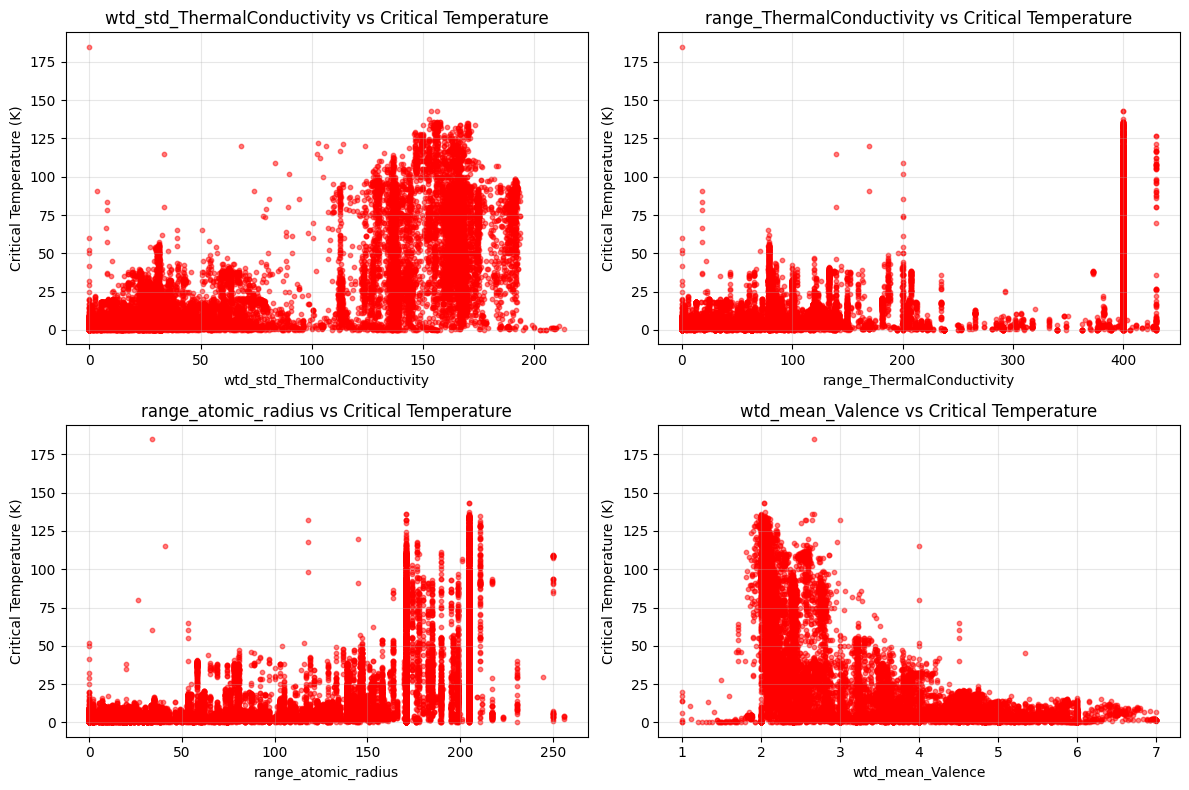


=== CORRELATION WITH CRITICAL TEMPERATURE ===
number_of_elements       : 0.601
mean_atomic_mass         : -0.114
wtd_mean_atomic_mass     : -0.312
gmean_atomic_mass        : -0.230
wtd_gmean_atomic_mass    : -0.370
entropy_atomic_mass      : 0.544
wtd_entropy_atomic_mass  : 0.627
range_atomic_mass        : 0.492
wtd_range_atomic_mass    : -0.337
std_atomic_mass          : 0.379
wtd_std_atomic_mass      : 0.359
mean_fie                 : 0.102
wtd_mean_fie             : 0.399
gmean_fie                : -0.025
wtd_gmean_fie            : 0.344
entropy_fie              : 0.568
wtd_entropy_fie          : 0.388
range_fie                : 0.601
wtd_range_fie            : 0.300
std_fie                  : 0.542
wtd_std_fie              : 0.582
mean_atomic_radius       : 0.105
wtd_mean_atomic_radius   : -0.297
gmean_atomic_radius      : -0.144
wtd_gmean_atomic_radius  : -0.405
entropy_atomic_radius    : 0.559
wtd_entropy_atomic_radius: 0.603
range_atomic_radius      : 0.654
wtd_range_atomic_rad

In [20]:
key_features = ['wtd_std_ThermalConductivity', 'range_ThermalConductivity', 'range_atomic_radius', 'wtd_mean_Valence']

# Check if these features exist, otherwise pick first 4 features
available_features = [f for f in key_features if f in X.columns]
if len(available_features) < 4:
    available_features = X.columns[:4]

print("=== EXAMINING KEY FEATURES ===")
for feature in available_features:
    print(f"\n{feature.upper()}:")
    print(f"  Range: {X[feature].min():.3f} to {X[feature].max():.3f}")
    print(f"  Average: {X[feature].mean():.3f}")

# Plot features vs critical temperature
plt.figure(figsize=(12, 8))

for i, feature in enumerate(available_features, 1):
    plt.subplot(2, 2, i)
    plt.scatter(X[feature], Y, alpha=0.5, color='red', s=10)
    plt.xlabel(feature)
    plt.ylabel('Critical Temperature (K)')
    plt.title(f'{feature} vs Critical Temperature')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find which feature has strongest relationship
print("\n=== CORRELATION WITH CRITICAL TEMPERATURE ===")
correlations = {}
for feature in X.columns[:82]:  # Check first 20 features
    corr = np.corrcoef(X[feature], Y)[0,1]
    correlations[feature] = abs(corr)
    print(f"{feature:25s}: {corr:.3f}")

best_feature = max(correlations, key=correlations.get)
print(f"\nBest feature so far: {best_feature} (correlation = {correlations[best_feature]:.3f})")